In [31]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score, precision_score, recall_score,precision_recall_curve
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [12]:
fold_1_train = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_1_train.csv')
fold_2_train = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_2_train.csv')
fold_3_train = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_3_train.csv')
fold_4_train = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_4_train.csv')
fold_5_train = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_5_train.csv')

fold_1_val = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_1_val.csv')
fold_2_val = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_2_val.csv')
fold_3_val = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_3_val.csv')
fold_4_val = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_4_val.csv')
fold_5_val = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_5_val.csv')

In [13]:
train_folds = [fold_1_train, fold_2_train, fold_3_train, fold_4_train, fold_5_train]
val_folds = [fold_1_val, fold_2_val, fold_3_val, fold_4_val, fold_5_val]

In [14]:
# Concatenate SMOTEd folds 1-4 for training
training_data = pd.concat([fold_1_train, fold_2_train, fold_3_train, fold_4_train])
X_train = training_data.drop(columns='fraud_bool')
y_train = training_data['fraud_bool']

# Use fold 5 as validation
X_val = fold_5_val.drop(columns='fraud_bool') 
y_val = fold_5_val['fraud_bool']

In [17]:
# Step 2: Initialize the Naive Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

# Step 3: Train the model on the training data
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, random_state=42)

In [18]:
# Step 4: Evaluate the model on the validation set
y_pred = rf.predict(X_val)

# Classification report for precision, recall, F1-score, and accuracy
print("Classification Report on Validation Set:")
print(classification_report(y_val, y_pred))

# Confusion matrix for false positives and false negatives
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))

# SROC AUC score for model performance
roc_auc = roc_auc_score(y_val, rf.predict_proba(X_val)[:, 1])
print(f'ROC AUC on Validation Set: {roc_auc:.2f}')

# Calculate F1-score
f1 = f1_score(y_val, y_pred)
print(f'F1 Score on Validation Set: {f1:.4f}')

Classification Report on Validation Set:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97    178711
           1       0.08      0.41      0.14      1920

    accuracy                           0.95    180631
   macro avg       0.54      0.68      0.56    180631
weighted avg       0.98      0.95      0.96    180631

Confusion Matrix:
[[170111   8600]
 [  1136    784]]
ROC AUC on Validation Set: 0.85
F1 Score on Validation Set: 0.1387


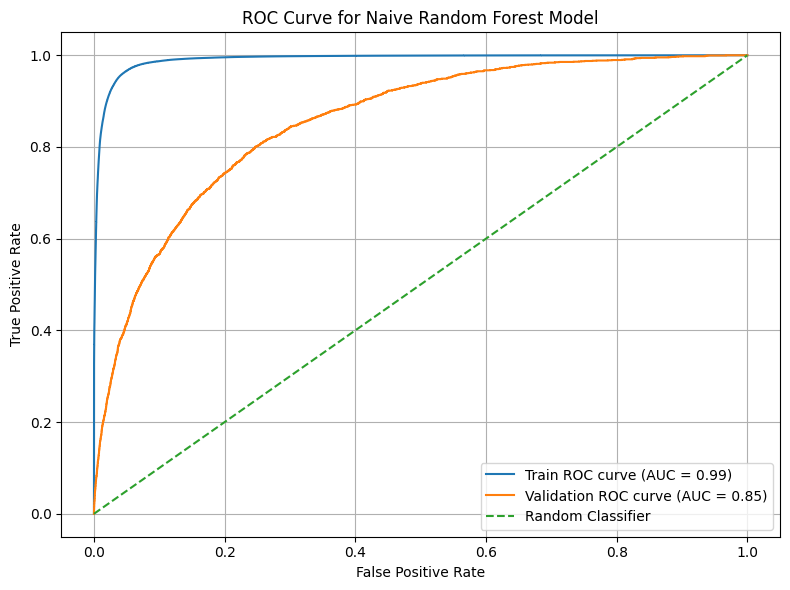

In [19]:
# Step 8: Plot ROC curve for the model's performance on Train vs. Test (Validation)
# Get the probabilities for the positive class (fraud)
y_train_proba = rf.predict_proba(X_train)[:, 1]
y_val_proba = rf.predict_proba(X_val)[:, 1]

# Compute ROC curve
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_proba)

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f'Train ROC curve (AUC = {roc_auc_score(y_train, y_train_proba):.2f})')
plt.plot(fpr_val, tpr_val, label=f'Validation ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Naive Random Forest Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, confusion_matrix, f1_score
import pandas as pd
import os
import matplotlib.pyplot as plt

In [21]:
# Define the objective function for Optuna
def objective(trial):
    # Hyperparameters to tune
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),  # Number of trees
        'max_depth': trial.suggest_int('max_depth', 10, 15),  # Maximum depth of the tree
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),  # Min samples required to split a node
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 4),  # Min samples required to be at a leaf node
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2'])  # Number of features to consider
    }

    # Create the Random Forest model with the suggested hyperparameters
    rf = RandomForestClassifier(**param, random_state=42)

    auc_roc = 0
    auc_pr = 0
    f1_score_avg = 0
    fold_classification_report = ""

    # Loop through the 4 folds for training and tuning
    for i in range(4):  # Only use folds 1-4 for training and tuning
        # Load training data for the current fold
        fold_train_data = pd.read_csv(f"/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_{i+1}_train.csv")
        
        # Separate features and target variable
        X_train_fold = fold_train_data.drop(columns='fraud_bool')
        y_train_fold = fold_train_data['fraud_bool']

        # Fit the model with the current fold's training data
        rf.fit(X_train_fold, y_train_fold)

        # Predict and calculate the probabilities on the current fold
        y_pred_fold = rf.predict(X_train_fold)
        y_proba_fold = rf.predict_proba(X_train_fold)[:, 1]  # Get probability for the positive class (fraud)

        # Calculate the evaluation metrics
        auc_roc += roc_auc_score(y_train_fold, y_proba_fold)
        auc_pr += average_precision_score(y_train_fold, y_proba_fold)
        f1_score_avg += f1_score(y_train_fold, y_pred_fold)

        # Get classification report for the fold
        fold_classification_report += f"\nFold {i+1} Classification Report:\n"
        fold_classification_report += classification_report(y_train_fold, y_pred_fold)

    # Calculate the average AUC-ROC, AUC-PR, and F1-score across all folds
    auc_roc /= 4  # Average over folds 1-4
    auc_pr /= 4
    f1_score_avg /= 4

    # Print metrics
    print(f"Average AUC-ROC: {auc_roc:.4f}")
    print(f"Average AUC-PR: {auc_pr:.4f}")
    print(f"Average F1-Score: {f1_score_avg:.4f}")
    print(fold_classification_report)

    # Return the f1-score as the objective to maximize
    return f1_score_avg  


In [22]:

# Create an Optuna study and optimize the objective
study = optuna.create_study(direction='maximize')  # Maximize F1
study.optimize(objective, n_trials=10, n_jobs= -1)  # Perform 10 trials of optimization

# Print the best parameters and the corresponding AUC-ROC score
print(f"Best hyperparameters: {study.best_params}")
print(f"Best AUC-ROC: {study.best_value:.4f}")



[I 2025-04-10 00:58:43,918] A new study created in memory with name: no-name-66b388b5-da5c-4755-be7e-7fa0d7b921b8


[I 2025-04-10 01:57:09,126] Trial 7 finished with value: 0.957827123310994 and parameters: {'n_estimators': 50, 'max_depth': 10, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 7 with value: 0.957827123310994.


Average AUC-ROC: 0.9911
Average AUC-PR: 0.9907
Average F1-Score: 0.9578

Fold 1 Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96    714844
           1       0.95      0.97      0.96    714844

    accuracy                           0.96   1429688
   macro avg       0.96      0.96      0.96   1429688
weighted avg       0.96      0.96      0.96   1429688

Fold 2 Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96    714845
           1       0.95      0.96      0.96    714845

    accuracy                           0.96   1429690
   macro avg       0.96      0.96      0.96   1429690
weighted avg       0.96      0.96      0.96   1429690

Fold 3 Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96    714845
           1       0.95      0.97      0.96    714845

    accuracy       

[I 2025-04-10 02:46:10,600] Trial 5 finished with value: 0.9649939197828201 and parameters: {'n_estimators': 64, 'max_depth': 11, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 5 with value: 0.9649939197828201.


Average AUC-ROC: 0.9931
Average AUC-PR: 0.9928
Average F1-Score: 0.9650

Fold 1 Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96    714844
           1       0.96      0.97      0.96    714844

    accuracy                           0.96   1429688
   macro avg       0.96      0.96      0.96   1429688
weighted avg       0.96      0.96      0.96   1429688

Fold 2 Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96    714845
           1       0.96      0.97      0.97    714845

    accuracy                           0.96   1429690
   macro avg       0.97      0.96      0.96   1429690
weighted avg       0.97      0.96      0.96   1429690

Fold 3 Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97    714845
           1       0.96      0.97      0.97    714845

    accuracy       

...

Average AUC-ROC: 0.9915
Average AUC-PR: 0.9911
Average F1-Score: 0.9598

Fold 1 Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96    714844
           1       0.95      0.97      0.96    714844

    accuracy                           0.96   1429688
   macro avg       0.96      0.96      0.96   1429688
weighted avg       0.96      0.96      0.96   1429688

Fold 2 Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96    714845
           1       0.95      0.97      0.96    714845

    accuracy                           0.96   1429690
   macro avg       0.96      0.96      0.96   1429690
weighted avg       0.96      0.96      0.96   1429690

Fold 3 Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96    714845
           1       0.95      0.97      0.96    714845

    accuracy       

[I 2025-04-10 04:02:54,806] Trial 1 finished with value: 0.9770388405644787 and parameters: {'n_estimators': 119, 'max_depth': 14, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.9770388405644787.


Average AUC-ROC: 0.9966
Average AUC-PR: 0.9965
Average F1-Score: 0.9770

Fold 1 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98    714844
           1       0.97      0.98      0.98    714844

    accuracy                           0.98   1429688
   macro avg       0.98      0.98      0.98   1429688
weighted avg       0.98      0.98      0.98   1429688

Fold 2 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98    714845
           1       0.97      0.98      0.98    714845

    accuracy                           0.98   1429690
   macro avg       0.98      0.98      0.98   1429690
weighted avg       0.98      0.98      0.98   1429690

Fold 3 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98    714845
           1       0.97      0.99      0.98    714845

    accuracy       

[I 2025-04-10 04:04:44,131] Trial 9 finished with value: 0.9791445213682615 and parameters: {'n_estimators': 98, 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 9 with value: 0.9791445213682615.


Average AUC-ROC: 0.9974
Average AUC-PR: 0.9973
Average F1-Score: 0.9791

Fold 1 Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98    714844
           1       0.97      0.99      0.98    714844

    accuracy                           0.98   1429688
   macro avg       0.98      0.98      0.98   1429688
weighted avg       0.98      0.98      0.98   1429688

Fold 2 Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98    714845
           1       0.97      0.99      0.98    714845

    accuracy                           0.98   1429690
   macro avg       0.98      0.98      0.98   1429690
weighted avg       0.98      0.98      0.98   1429690

Fold 3 Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98    714845
           1       0.97      0.99      0.98    714845

    accuracy       

In [23]:
# Retraining the final model with the best hyperparameters on the entire training dataset (folds 1-4)
# Load all training data (from folds 1-4) to retrain the model
final_train_data = pd.concat([pd.read_csv(f"/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_{i+1}_train.csv") for i in range(4)])
X_train_final = final_train_data.drop(columns='fraud_bool')
y_train_final = final_train_data['fraud_bool']

# Initialize Random Forest with the best hyperparameters
final_rf = RandomForestClassifier(**study.best_params, random_state=42)

In [25]:
# Fit the model with the entire training data
final_rf.fit(X_train_final, y_train_final)

RandomForestClassifier(max_depth=15, max_features='log2', min_samples_split=5,
                       n_estimators=98, random_state=42)

In [26]:
# Load fold 5 as the validation set for final evaluation (fold 5 is untouched during training and tuning)
X_val = fold_5_val.drop(columns='fraud_bool')
y_val = fold_5_val['fraud_bool']

In [27]:
# Make predictions on the test set
y_pred_test = final_rf.predict(X_val)
y_proba_test = final_rf.predict_proba(X_val)[:, 1]  # Get probability for the positive class (fraud)

In [28]:
# Print classification report and confusion matrix for the test set
print("\nFinal Model Evaluation on Test Set:")
print(classification_report(y_val, y_pred_test))
print(f"ROC AUC on Test Set: {roc_auc_score(y_val, y_proba_test):.4f}")

# Print confusion matrix
cm = confusion_matrix(y_val, y_pred_test)
print("Confusion Matrix:")
print(cm)


Final Model Evaluation on Test Set:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98    178711
           1       0.13      0.40      0.20      1920

    accuracy                           0.97    180631
   macro avg       0.56      0.68      0.59    180631
weighted avg       0.98      0.97      0.97    180631

ROC AUC on Test Set: 0.9259
Confusion Matrix:
[[173565   5146]
 [  1156    764]]


In [32]:
def evaluate_model(y_true, y_pred, y_proba=None, plot_pr_curve=True):
    print("Classification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    # Key Metrics
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\nPrecision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    metrics = {
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': cm.tolist()
    }

    # Probabilistic metrics
    if y_proba is not None:
        pr_auc = average_precision_score(y_true, y_proba)
        metrics['auc_pr'] = pr_auc
        print(f"AUC-PR (Average Precision): {pr_auc:.4f}")

        roc_auc = roc_auc_score(y_true, y_proba)
        metrics['roc_auc'] = roc_auc
        print(f"ROC AUC:                   {roc_auc:.4f}")

        if plot_pr_curve:
            precision_pts, recall_pts, _ = precision_recall_curve(y_true, y_proba)
            plt.figure(figsize=(6, 5))
            plt.plot(recall_pts, precision_pts, marker='.', label='PR Curve')
            plt.xlabel('Recall')
            plt.ylabel('Precision')
            plt.title(f'Precision-Recall Curve (AUC = {pr_auc:.4f})')
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()

    return metrics

Classification Report:
              precision    recall  f1-score   support

           0     0.9934    0.9712    0.9822    178711
           1     0.1293    0.3979    0.1951      1920

    accuracy                         0.9651    180631
   macro avg     0.5613    0.6846    0.5887    180631
weighted avg     0.9842    0.9651    0.9738    180631


Confusion Matrix:
[[173565   5146]
 [  1156    764]]

Precision: 0.1293
Recall:    0.3979
F1 Score:  0.1951
AUC-PR (Average Precision): 0.1259
ROC AUC:                   0.9259


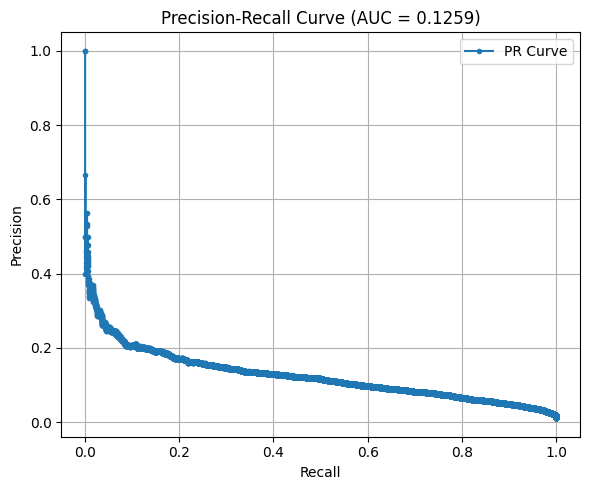

{'precision': 0.12927241962774957,
 'recall': 0.39791666666666664,
 'f1_score': 0.19514687100894,
 'confusion_matrix': [[173565, 5146], [1156, 764]],
 'auc_pr': np.float64(0.12589241360076764),
 'roc_auc': np.float64(0.925907024819401)}

In [34]:
evaluate_model(y_val, y_pred_test, y_proba_test)